# Cell selection: concept, maintenance, and probe cells

This notebook identifies visually selective **concept cells**, **maintenance cells**, and **probe cells** in MTL for dataset 000469, following the permutation-based criteria from the working memory task paper.

We:
- Load spike and trial data from all sessions in `000469/`
- Define encoding, maintenance, baseline, and probe epochs
- Run permutation tests to classify neurons
- Summarize proportions of each cell type, focusing on MTL.


In [10]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import f_oneway
from tqdm import tqdm

from nwb_analysis.data_loading import load_nwb_file, get_subject_files
from nwb_analysis.epochs import extract_epoch_times
from nwb_analysis.regions import extract_region_channels

DATA_ROOT = Path("/Users/jundazhu/SBCAT/000469")

# Configuration: Number of permutations for statistical tests
# Note: Original paper does not specify this number
# Minimum n=20 needed to resolve p<0.05 (gives minimum p-value = 1/21 ≈ 0.0476)
N_PERMUTATIONS = 100

# Get all files and filter for ses-2 only
all_files = get_subject_files(DATA_ROOT)
all_files = [f for f in all_files if "ses-2" in str(f)]
print(f"Found {len(all_files)} NWB files with ses-2")


Found 21 NWB files with ses-2


In [11]:
def load_session(path: Path):
    """Load one NWB session and return (nwbfile, trials_df, electrodes_df).

    Keeps the NWBHDF5IO handle inside the returned dict so we can close later if needed.
    """
    data = load_nwb_file(path)
    nwbfile = data["nwbfile"]
    trials_df = data.get("trials", None)
    electrodes_df = data.get("electrodes", None)
    return data, nwbfile, trials_df, electrodes_df


# Test load one session
session_data, example_nwb, example_trials, example_electrodes = load_session(all_files[0])
print(f"Example session: {len(example_trials)} trials, {len(example_nwb.units)} units")


Example session: 135 trials, 40 units


## Epoch definitions and firing rate extraction

We now define encoding, maintenance, baseline (fixation), and probe windows per trial and compute per-trial firing rates for each unit.


In [12]:
def get_epoch_windows_for_trial(trial_row: pd.Series):
    """Return dict of epoch windows (start, end) in seconds for one trial.

    Encoding windows: 0.2–1.0 s after each encoding onset.
    Maintenance: 0–2.5 s after maintenance onset.
    Baseline: first 0.5 s of fixation.
    Probe: 0.2–1.0 s after probe onset.
    """
    windows = {}

    # Baseline fixation (first 500 ms of fixation cross)
    if "timestamps_FixationCross" in trial_row:
        fix_start = trial_row["timestamps_FixationCross"]
        if fix_start > 0:
            windows["baseline"] = (fix_start, fix_start + 0.5)

    # Maintenance (0–2500 ms from maintenance onset)
    if "timestamps_Maintenance" in trial_row:
        maint_start = trial_row["timestamps_Maintenance"]
        if maint_start > 0:
            windows["maintenance"] = (maint_start, maint_start + 2.5)

    # Probe (200–1000 ms from probe onset)
    if "timestamps_Probe" in trial_row:
        probe_start = trial_row["timestamps_Probe"]
        if probe_start > 0:
            windows["probe"] = (probe_start + 0.2, probe_start + 1.0)

    # Encoding windows: per encoding onset
    for enc_idx in (1, 2, 3):
        ts_col = f"timestamps_Encoding{enc_idx}"
        if ts_col in trial_row:
            enc_start = trial_row[ts_col]
            if enc_start > 0:
                windows[f"encoding{enc_idx}"] = (enc_start + 0.2, enc_start + 1.0)

    return windows


def compute_rate_in_window(spike_times: np.ndarray, start: float, end: float) -> float:
    """Compute firing rate (Hz) in [start, end) for given spike times (seconds)."""
    if spike_times is None or len(spike_times) == 0:
        return 0.0
    mask = (spike_times >= start) & (spike_times < end)
    return float(mask.sum()) / max(end - start, 1e-6)


def compute_trial_rates_for_unit(nwbfile, unit_idx: int, trials_df: pd.DataFrame) -> dict:
    """Compute per-trial firing rates for key epochs for a single unit.

    Returns dict of arrays keyed by epoch name.
    """
    spike_times = np.array(nwbfile.units['spike_times'][unit_idx][:])

    baseline_rates = []
    maintenance_rates = []
    probe_rates = []
    encoding_rates = {1: [], 2: [], 3: []}

    for trial_id, trial in trials_df.iterrows():
        windows = get_epoch_windows_for_trial(trial)

        if "baseline" in windows:
            baseline_rates.append(compute_rate_in_window(spike_times, *windows["baseline"]))
        else:
            baseline_rates.append(np.nan)

        if "maintenance" in windows:
            maintenance_rates.append(compute_rate_in_window(spike_times, *windows["maintenance"]))
        else:
            maintenance_rates.append(np.nan)

        if "probe" in windows:
            probe_rates.append(compute_rate_in_window(spike_times, *windows["probe"]))
        else:
            probe_rates.append(np.nan)

        for enc_idx in (1, 2, 3):
            key = f"encoding{enc_idx}"
            if key in windows:
                encoding_rates[enc_idx].append(compute_rate_in_window(spike_times, *windows[key]))
            else:
                encoding_rates[enc_idx].append(np.nan)

    return {
        "baseline": np.array(baseline_rates, dtype=float),
        "maintenance": np.array(maintenance_rates, dtype=float),
        "probe": np.array(probe_rates, dtype=float),
        "encoding": {k: np.array(v, dtype=float) for k, v in encoding_rates.items()},
    }


## Permutation tests for cell classification

We implement permutation-based tests for:
1. **Concept cells**: ANOVA on encoding firing rates by image identity, then t-test for preferred vs. non-preferred
2. **Maintenance cells**: Compare maintenance vs. baseline firing rates
3. **Probe cells**: Compare probe vs. encoding and probe vs. maintenance firing rates


In [13]:
def permutation_anova(groups, n_permutations=N_PERMUTATIONS):
    """One-way ANOVA with permutation testing.
    
    Args:
        groups: list of arrays, one per group
        n_permutations: number of permutations
    
    Returns:
        p_value: permutation-based p-value
    """
    # Remove groups with no data
    groups = [g[~np.isnan(g)] for g in groups if len(g[~np.isnan(g)]) > 0]
    if len(groups) < 2:
        return 1.0
    
    # Observed F-statistic
    f_obs, _ = f_oneway(*groups)
    
    # Permutation test
    all_data = np.concatenate(groups)
    n_per_group = [len(g) for g in groups]
    
    f_perm = []
    for _ in range(n_permutations):
        np.random.shuffle(all_data)
        perm_groups = []
        start = 0
        for n in n_per_group:
            perm_groups.append(all_data[start:start+n])
            start += n
        f_perm_val, _ = f_oneway(*perm_groups)
        f_perm.append(f_perm_val)
    
    # Two-tailed p-value (though F-stat is always positive)
    p_value = np.mean(np.array(f_perm) >= f_obs)
    return p_value


def permutation_ttest(group1, group2, n_permutations=N_PERMUTATIONS):
    """Two-sample t-test with permutation testing.
    
    Args:
        group1, group2: arrays of values
        n_permutations: number of permutations
    
    Returns:
        p_value: permutation-based p-value (one-tailed: group1 > group2)
    """
    group1 = group1[~np.isnan(group1)]
    group2 = group2[~np.isnan(group2)]
    
    if len(group1) == 0 or len(group2) == 0:
        return 1.0
    
    # Observed difference in means
    diff_obs = np.mean(group1) - np.mean(group2)
    
    # Permutation test
    all_data = np.concatenate([group1, group2])
    n1 = len(group1)
    
    diff_perm = []
    for _ in range(n_permutations):
        np.random.shuffle(all_data)
        perm_diff = np.mean(all_data[:n1]) - np.mean(all_data[n1:])
        diff_perm.append(perm_diff)
    
    # One-tailed p-value: P(perm_diff >= obs_diff)
    p_value = np.mean(np.array(diff_perm) >= diff_obs)
    return p_value


In [14]:
def test_concept_cell(nwbfile, unit_idx: int, trials_df: pd.DataFrame, n_permutations=N_PERMUTATIONS, alpha=0.05):
    """Test if a unit is a concept cell.
    
    Criteria:
    1. Permutation ANOVA on encoding firing rates by image identity (P < 0.05)
    2. Preferred image firing rate > all other images (permutation t-test, P < 0.05)
    
    Returns:
        dict with keys: is_concept_cell, anova_p, preferred_vs_others_p, preferred_image_id
    """
    # Get encoding events with image IDs
    encoding_events = []
    for trial_id, trial in trials_df.iterrows():
        for enc_idx in (1, 2, 3):
            ts_col = f"timestamps_Encoding{enc_idx}"
            pic_col = f"loadsEnc{enc_idx}_PicIDs"
            if ts_col in trial and pic_col in trial:
                onset = trial[ts_col]
                pic_id = trial[pic_col]
                if onset > 0 and not pd.isna(pic_id) and pic_id != 0:
                    encoding_events.append({
                        "trial_id": trial_id,
                        "enc_idx": enc_idx,
                        "pic_id": int(pic_id),
                        "onset_time": float(onset),
                    })
    
    if len(encoding_events) == 0:
        return {"is_concept_cell": False, "anova_p": 1.0, "preferred_vs_others_p": 1.0, "preferred_image_id": None}
    
    # Compute firing rates for each encoding event
    spike_times = np.array(nwbfile.units['spike_times'][unit_idx][:])
    rates_by_image = {}
    
    for event in encoding_events:
        trial = trials_df.loc[event["trial_id"]]
        windows = get_epoch_windows_for_trial(trial)
        key = f"encoding{event['enc_idx']}"
        if key in windows:
            rate = compute_rate_in_window(spike_times, *windows[key])
            pic_id = event["pic_id"]
            if pic_id not in rates_by_image:
                rates_by_image[pic_id] = []
            rates_by_image[pic_id].append(rate)
    
    # Need at least 2 unique images
    unique_images = list(rates_by_image.keys())
    if len(unique_images) < 2:
        return {"is_concept_cell": False, "anova_p": 1.0, "preferred_vs_others_p": 1.0, "preferred_image_id": None}
    
    # Test 1: ANOVA on firing rates by image identity
    groups = [np.array(rates_by_image[img]) for img in unique_images]
    anova_p = permutation_anova(groups, n_permutations=n_permutations)
    
    if anova_p >= alpha:
        return {"is_concept_cell": False, "anova_p": anova_p, "preferred_vs_others_p": 1.0, "preferred_image_id": None}
    
    # Test 2: Preferred image vs. all others
    # Find preferred image (highest mean firing rate)
    mean_rates = {img: np.mean(rates_by_image[img]) for img in unique_images}
    preferred_image = max(mean_rates, key=mean_rates.get)
    
    preferred_rates = np.array(rates_by_image[preferred_image])
    non_preferred_rates = np.concatenate([np.array(rates_by_image[img]) for img in unique_images if img != preferred_image])
    
    preferred_vs_others_p = permutation_ttest(preferred_rates, non_preferred_rates, n_permutations=n_permutations)
    
    is_concept_cell = (anova_p < alpha) and (preferred_vs_others_p < alpha)
    
    return {
        "is_concept_cell": is_concept_cell,
        "anova_p": anova_p,
        "preferred_vs_others_p": preferred_vs_others_p,
        "preferred_image_id": preferred_image,
    }


In [15]:
def test_maintenance_cell(nwbfile, unit_idx: int, trials_df: pd.DataFrame, is_concept_cell=False, preferred_image_id=None, n_permutations=N_PERMUTATIONS, alpha=0.05):
    """Test if a unit is a maintenance cell.
    
    Criteria:
    1. Maintenance firing rate > baseline (permutation test, P < 0.05)
    2. If also a concept cell: maintenance for non-preferred stimuli > baseline (P < 0.05)
    
    Returns:
        dict with keys: is_maintenance_cell, maint_vs_baseline_p, nonpref_maint_vs_baseline_p
    """
    rates = compute_trial_rates_for_unit(nwbfile, unit_idx, trials_df)
    
    baseline_rates = rates["baseline"][~np.isnan(rates["baseline"])]
    maintenance_rates = rates["maintenance"][~np.isnan(rates["maintenance"])]
    
    if len(baseline_rates) == 0 or len(maintenance_rates) == 0:
        return {"is_maintenance_cell": False, "maint_vs_baseline_p": 1.0, "nonpref_maint_vs_baseline_p": 1.0}
    
    # Test 1: Maintenance vs. baseline (pooled across all images)
    maint_vs_baseline_p = permutation_ttest(maintenance_rates, baseline_rates, n_permutations=n_permutations)
    
    if maint_vs_baseline_p >= alpha:
        return {"is_maintenance_cell": False, "maint_vs_baseline_p": maint_vs_baseline_p, "nonpref_maint_vs_baseline_p": 1.0}
    
    # Test 2: If concept cell, check non-preferred stimuli maintenance > baseline
    nonpref_maint_vs_baseline_p = 1.0
    if is_concept_cell and preferred_image_id is not None:
        # Get maintenance rates for non-preferred image trials
        spike_times = np.array(nwbfile.units['spike_times'][unit_idx][:])
        nonpref_maint_rates = []
        
        for trial_id, trial in trials_df.iterrows():
            # Check if this trial has a non-preferred image
            has_nonpref = False
            for enc_idx in (1, 2, 3):
                pic_col = f"loadsEnc{enc_idx}_PicIDs"
                if pic_col in trial:
                    pic_id = trial[pic_col]
                    if not pd.isna(pic_id) and pic_id != 0 and int(pic_id) != preferred_image_id:
                        has_nonpref = True
                        break
            
            if has_nonpref:
                windows = get_epoch_windows_for_trial(trial)
                if "maintenance" in windows:
                    rate = compute_rate_in_window(spike_times, *windows["maintenance"])
                    nonpref_maint_rates.append(rate)
        
        if len(nonpref_maint_rates) > 0:
            nonpref_maint_rates = np.array(nonpref_maint_rates)
            nonpref_maint_vs_baseline_p = permutation_ttest(nonpref_maint_rates, baseline_rates, n_permutations=n_permutations)
    
    is_maintenance_cell = (maint_vs_baseline_p < alpha)
    if is_concept_cell:
        is_maintenance_cell = is_maintenance_cell and (nonpref_maint_vs_baseline_p < alpha)
    
    return {
        "is_maintenance_cell": is_maintenance_cell,
        "maint_vs_baseline_p": maint_vs_baseline_p,
        "nonpref_maint_vs_baseline_p": nonpref_maint_vs_baseline_p,
    }


In [16]:
def test_probe_cell(nwbfile, unit_idx: int, trials_df: pd.DataFrame, n_permutations=N_PERMUTATIONS, alpha=0.05):
    """Test if a unit is a probe cell.
    
    Criteria:
    1. Probe firing rate > encoding firing rate (permutation t-test, P < 0.05)
    2. Probe firing rate > maintenance firing rate (permutation t-test, P < 0.05)
    
    Returns:
        dict with keys: is_probe_cell, probe_vs_encoding_p, probe_vs_maintenance_p
    """
    rates = compute_trial_rates_for_unit(nwbfile, unit_idx, trials_df)
    
    # Combine all encoding epochs
    encoding_all = []
    for enc_idx in (1, 2, 3):
        enc_rates = rates["encoding"][enc_idx]
        encoding_all.extend(enc_rates[~np.isnan(enc_rates)])
    encoding_rates = np.array(encoding_all)
    
    probe_rates = rates["probe"][~np.isnan(rates["probe"])]
    maintenance_rates = rates["maintenance"][~np.isnan(rates["maintenance"])]
    
    if len(probe_rates) == 0:
        return {"is_probe_cell": False, "probe_vs_encoding_p": 1.0, "probe_vs_maintenance_p": 1.0}
    
    # Test 1: Probe vs. encoding
    probe_vs_encoding_p = 1.0
    if len(encoding_rates) > 0:
        probe_vs_encoding_p = permutation_ttest(probe_rates, encoding_rates, n_permutations=n_permutations)
    
    # Test 2: Probe vs. maintenance
    probe_vs_maintenance_p = 1.0
    if len(maintenance_rates) > 0:
        probe_vs_maintenance_p = permutation_ttest(probe_rates, maintenance_rates, n_permutations=n_permutations)
    
    is_probe_cell = (probe_vs_encoding_p < alpha) and (probe_vs_maintenance_p < alpha)
    
    return {
        "is_probe_cell": is_probe_cell,
        "probe_vs_encoding_p": probe_vs_encoding_p,
        "probe_vs_maintenance_p": probe_vs_maintenance_p,
    }


## Process all sessions and classify neurons

We iterate over all sessions in 000469, classify each neuron, and restrict analysis to MTL regions.


In [17]:
def get_unit_region(nwbfile, unit_idx: int, electrodes_df: pd.DataFrame):
    """Get brain region for a unit based on its electrode.
    
    Uses the DataFrame approach from null_space.ipynb which robustly handles
    electrode references stored as DataFrame objects.
    
    Returns MTL region name if unit is in MTL, None otherwise.
    """
    if nwbfile.units is None or electrodes_df is None or electrodes_df.empty:
        return None
    
    if 'location' not in electrodes_df.columns:
        return None
    
    try:
        # Convert units to DataFrame (most robust approach)
        units_df = nwbfile.units.to_dataframe()
        
        if 'electrodes' not in units_df.columns:
            return None
        
        # Get electrode info for this unit
        electrode_info = units_df.iloc[unit_idx]['electrodes']
        
        # Extract electrode index - handle DataFrame objects (most common case)
        electrode_idx = None
        if isinstance(electrode_info, pd.DataFrame):
            # DataFrame object: extract index from the DataFrame's index
            if len(electrode_info.index) > 0:
                electrode_idx = int(electrode_info.index[0])
        elif hasattr(electrode_info, 'index') and len(electrode_info.index) > 0:
            # Object with index attribute
            electrode_idx = int(electrode_info.index[0])
        elif pd.notna(electrode_info):
            # Scalar value
            try:
                electrode_idx = int(electrode_info)
            except (ValueError, TypeError):
                pass
        
        if electrode_idx is None:
            return None
        
        # Get location from electrodes table
        if electrode_idx not in electrodes_df.index:
            return None
        
        location_str = str(electrodes_df.loc[electrode_idx, 'location']).lower()
        
        # Map to MTL regions (using pattern matching like cfc.py _infer_area)
        if 'hipp' in location_str:
            return 'Hippocampus'
        elif 'amyg' in location_str:
            return 'Amygdala'
        elif 'entorhinal' in location_str:
            return 'Entorhinal'
        elif 'parahippocampal' in location_str:
            return 'Parahippocampal'
        
        return None
    except Exception as e:
        return None


def is_mtl_region(region):
    """Check if region is part of MTL."""
    mtl_regions = ['Hippocampus', 'Amygdala', 'Entorhinal', 'Parahippocampal']
    return region in mtl_regions


In [18]:
# First, count MTL units across all sessions to verify region matching
print("Counting MTL units across all sessions...")
mtl_counts = {}
total_units = 0
total_mtl_units = 0
units_with_electrodes = 0
units_without_electrodes = 0
electrode_idx_mismatches = 0

for file_path in tqdm(all_files, desc="Scanning sessions"):
    try:
        data, nwbfile, trials_df, electrodes_df = load_session(file_path)
        
        if nwbfile.units is None:
            data["io"].close()
            continue
        
        if electrodes_df is None or electrodes_df.empty:
            data["io"].close()
            continue
        
        session_units = 0
        session_mtl_units = 0
        
        for unit_idx in range(len(nwbfile.units)):
            total_units += 1
            session_units += 1
            
            # Check if unit has electrode reference (using same logic as get_unit_region)
            has_electrode = False
            electrode_idx = None
            
            try:
                units_df = nwbfile.units.to_dataframe()
                if 'electrodes' in units_df.columns:
                    electrode_info = units_df.iloc[unit_idx]['electrodes']
                    if isinstance(electrode_info, pd.DataFrame):
                        if len(electrode_info.index) > 0:
                            electrode_idx = int(electrode_info.index[0])
                            has_electrode = True
                    elif hasattr(electrode_info, 'index') and len(electrode_info.index) > 0:
                        electrode_idx = int(electrode_info.index[0])
                        has_electrode = True
                    elif pd.notna(electrode_info):
                        try:
                            electrode_idx = int(electrode_info)
                            has_electrode = True
                        except (ValueError, TypeError):
                            pass
            except Exception:
                pass
            
            if has_electrode:
                units_with_electrodes += 1
                if electrode_idx not in electrodes_df.index:
                    electrode_idx_mismatches += 1
            else:
                units_without_electrodes += 1
            
            region = get_unit_region(nwbfile, unit_idx, electrodes_df)
            if is_mtl_region(region):
                total_mtl_units += 1
                session_mtl_units += 1
                if region not in mtl_counts:
                    mtl_counts[region] = 0
                mtl_counts[region] += 1
        
        data["io"].close()
    except Exception as e:
        print(f"Error scanning {file_path.name}: {e}")
        import traceback
        traceback.print_exc()
        continue

print(f"\nTotal units across all sessions: {total_units}")
print(f"Units with electrode references: {units_with_electrodes}")
print(f"Units without electrode references: {units_without_electrodes}")
print(f"Electrode index mismatches (not in electrodes_df.index): {electrode_idx_mismatches}")
print(f"\nTotal MTL units: {total_mtl_units}")
if total_mtl_units > 0:
    print(f"\nMTL units by region:")
    for region, count in sorted(mtl_counts.items()):
        print(f"  {region}: {count}")
else:
    print("\nWARNING: No MTL units found!")
    print("This suggests either:")
    print("  1. Location strings don't contain 'hipp', 'amyg', 'entorhinal', or 'parahippocampal'")
    print("  2. Units are not properly linked to electrodes")
    print("  3. Electrode indices don't match between units and electrodes table")
print(f"\n{'='*60}")

# Process all sessions
all_results = []

for file_path in tqdm(all_files, desc="Processing sessions"):
    try:
        data, nwbfile, trials_df, electrodes_df = load_session(file_path)
        
        if nwbfile.units is None or trials_df is None:
            data["io"].close()
            continue
        
        subject_id = getattr(nwbfile.subject, "subject_id", None) if nwbfile.subject is not None else None
        session_id = file_path.stem
        
        session_mtl_count = 0
        
        # Process each unit
        for unit_idx in range(len(nwbfile.units)):
            region = get_unit_region(nwbfile, unit_idx, electrodes_df)
            
            # Only analyze MTL neurons
            if not is_mtl_region(region):
                continue
            
            session_mtl_count += 1
            
            # Classify cell types
            concept_result = test_concept_cell(nwbfile, unit_idx, trials_df, n_permutations=N_PERMUTATIONS)
            maintenance_result = test_maintenance_cell(
                nwbfile, unit_idx, trials_df,
                is_concept_cell=concept_result["is_concept_cell"],
                preferred_image_id=concept_result["preferred_image_id"],
                n_permutations=N_PERMUTATIONS
            )
            probe_result = test_probe_cell(nwbfile, unit_idx, trials_df, n_permutations=N_PERMUTATIONS)
            
            all_results.append({
                "subject_id": subject_id,
                "session_id": session_id,
                "unit_idx": unit_idx,
                "region": region,
                "is_concept_cell": concept_result["is_concept_cell"],
                "is_maintenance_cell": maintenance_result["is_maintenance_cell"],
                "is_probe_cell": probe_result["is_probe_cell"],
                "concept_anova_p": concept_result["anova_p"],
                "concept_preferred_p": concept_result["preferred_vs_others_p"],
                "maint_vs_baseline_p": maintenance_result["maint_vs_baseline_p"],
                "probe_vs_encoding_p": probe_result["probe_vs_encoding_p"],
                "probe_vs_maintenance_p": probe_result["probe_vs_maintenance_p"],
            })
        
        if session_mtl_count > 0:
            print(f"{session_id}: {session_mtl_count} MTL units")
        
        data["io"].close()
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        import traceback
        traceback.print_exc()
        continue

results_df = pd.DataFrame(all_results)
print(f"\n{'='*60}")
print(f"Processed {len(results_df)} MTL neurons across {len(all_files)} sessions")
if len(results_df) > 0:
    print(f"\nResults summary:")
    print(results_df[["is_concept_cell", "is_maintenance_cell", "is_probe_cell"]].sum())
    print(f"\nBy region:")
    print(results_df.groupby("region").size())
else:
    print("WARNING: No MTL neurons found! Check region matching logic.")


Counting MTL units across all sessions...


Scanning sessions: 100%|██████████| 21/21 [00:09<00:00,  2.17it/s]



Total units across all sessions: 902
Units with electrode references: 902
Units without electrode references: 0
Electrode index mismatches (not in electrodes_df.index): 0

Total MTL units: 449

MTL units by region:
  Amygdala: 259
  Hippocampus: 190



Processing sessions:   5%|▍         | 1/21 [00:00<00:11,  1.74it/s]

sub-1_ses-2_ecephys+image: 8 MTL units


...

sub-7_ses-2_ecephys+image: 16 MTL units


Processing sessions:  95%|█████████▌| 20/21 [00:23<00:01,  1.07s/it]

sub-8_ses-2_ecephys+image: 27 MTL units


Processing sessions: 100%|██████████| 21/21 [00:25<00:00,  1.21s/it]

sub-9_ses-2_ecephys+image: 40 MTL units

Processed 449 MTL neurons across 21 sessions

Results summary:
is_concept_cell        131
is_maintenance_cell    123
is_probe_cell           63
dtype: int64

By region:
region
Amygdala       259
Hippocampus    190
dtype: int64


## Summary statistics and visualization

Compute proportions of each cell type in MTL, matching the target result: ~20.94% concept cells during encoding period.


In [19]:
# Summary statistics
total_mtl_neurons = len(results_df)
n_concept = results_df["is_concept_cell"].sum()
n_maintenance = results_df["is_maintenance_cell"].sum()
n_probe = results_df["is_probe_cell"].sum()

pct_concept = 100 * n_concept / total_mtl_neurons if total_mtl_neurons > 0 else 0
pct_maintenance = 100 * n_maintenance / total_mtl_neurons if total_mtl_neurons > 0 else 0
pct_probe = 100 * n_probe / total_mtl_neurons if total_mtl_neurons > 0 else 0

print("=" * 60)
print("CELL CLASSIFICATION SUMMARY (MTL)")
print("=" * 60)
print(f"Total MTL neurons analyzed: {total_mtl_neurons}")
print(f"\nConcept cells:")
print(f"  Count: {n_concept} ({pct_concept:.2f}%)")
print(f"  Target: ~20.94%")
print(f"\nMaintenance cells:")
print(f"  Count: {n_maintenance} ({pct_maintenance:.2f}%)")
print(f"\nProbe cells:")
print(f"  Count: {n_probe} ({pct_probe:.2f}%)")
print("=" * 60)

# Breakdown by region
if len(results_df) > 0:
    print("\nBreakdown by region:")
    region_summary = results_df.groupby("region").agg({
        "is_concept_cell": ["count", "sum"],
        "is_maintenance_cell": "sum",
        "is_probe_cell": "sum",
    }).round(2)
    print(region_summary)


CELL CLASSIFICATION SUMMARY (MTL)
Total MTL neurons analyzed: 449

Concept cells:
  Count: 131 (29.18%)
  Target: ~20.94%

Maintenance cells:
  Count: 123 (27.39%)

Probe cells:
  Count: 63 (14.03%)

Breakdown by region:
            is_concept_cell     is_maintenance_cell is_probe_cell
                      count sum                 sum           sum
region                                                           
Amygdala                259  91                  68            37
Hippocampus             190  40                  55            26


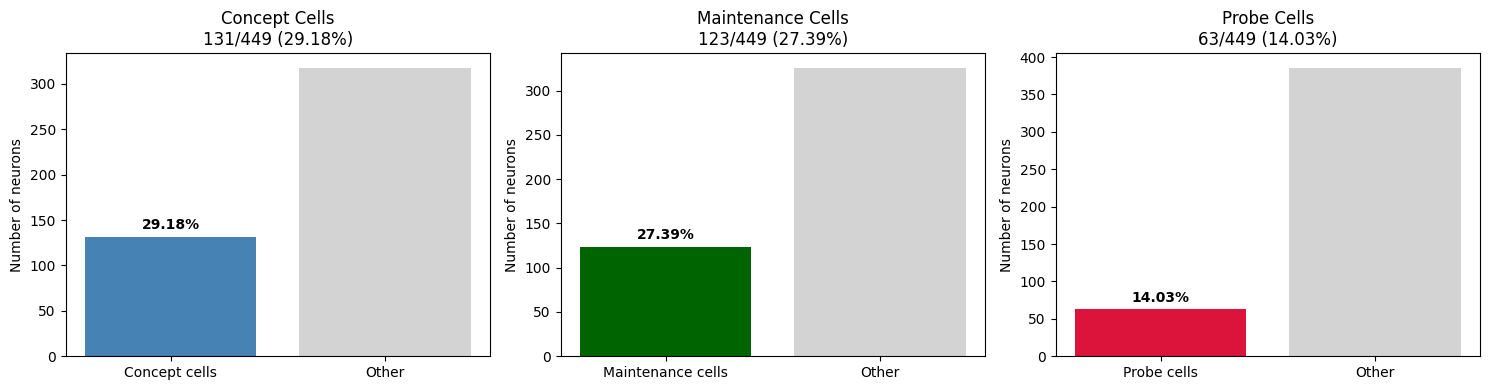

In [20]:
import matplotlib.pyplot as plt

# Create summary plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Concept cells
concept_counts = [n_concept, total_mtl_neurons - n_concept]
axes[0].bar(["Concept cells", "Other"], concept_counts, color=["steelblue", "lightgray"])
axes[0].set_ylabel("Number of neurons")
axes[0].set_title(f"Concept Cells\n{n_concept}/{total_mtl_neurons} ({pct_concept:.2f}%)")
axes[0].text(0, n_concept + total_mtl_neurons * 0.02, f"{pct_concept:.2f}%", ha="center", fontweight="bold")

# Maintenance cells
maint_counts = [n_maintenance, total_mtl_neurons - n_maintenance]
axes[1].bar(["Maintenance cells", "Other"], maint_counts, color=["darkgreen", "lightgray"])
axes[1].set_ylabel("Number of neurons")
axes[1].set_title(f"Maintenance Cells\n{n_maintenance}/{total_mtl_neurons} ({pct_maintenance:.2f}%)")
axes[1].text(0, n_maintenance + total_mtl_neurons * 0.02, f"{pct_maintenance:.2f}%", ha="center", fontweight="bold")

# Probe cells
probe_counts = [n_probe, total_mtl_neurons - n_probe]
axes[2].bar(["Probe cells", "Other"], probe_counts, color=["crimson", "lightgray"])
axes[2].set_ylabel("Number of neurons")
axes[2].set_title(f"Probe Cells\n{n_probe}/{total_mtl_neurons} ({pct_probe:.2f}%)")
axes[2].text(0, n_probe + total_mtl_neurons * 0.02, f"{pct_probe:.2f}%", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("analysis_output/cell_classification_summary.png", dpi=150, bbox_inches="tight")
plt.show()


In [21]:
# Save results to CSV
results_df.to_csv("analysis_output/cell_classification_results.csv", index=False)
print("Results saved to analysis_output/cell_classification_results.csv")

# Create detailed summary table
summary_table = pd.DataFrame({
    "Cell Type": ["Concept cells", "Maintenance cells", "Probe cells"],
    "Count": [n_concept, n_maintenance, n_probe],
    "Total MTL Neurons": [total_mtl_neurons, total_mtl_neurons, total_mtl_neurons],
    "Percentage": [pct_concept, pct_maintenance, pct_probe],
})
summary_table.to_csv("analysis_output/cell_classification_summary.csv", index=False)
print("Summary saved to analysis_output/cell_classification_summary.csv")
print("\nSummary table:")
print(summary_table.to_string(index=False))


Results saved to analysis_output/cell_classification_results.csv
Summary saved to analysis_output/cell_classification_summary.csv

Summary table:
        Cell Type  Count  Total MTL Neurons  Percentage
    Concept cells    131                449   29.175947
Maintenance cells    123                449   27.394209
      Probe cells     63                449   14.031180


## Methods and Parameters

### Time Windows
- **Encoding period**: 200–1000 ms after stimulus onset (per encoding event)
- **Maintenance period**: 0–2500 ms after maintenance onset
- **Baseline**: First 500 ms of fixation cross presentation
- **Probe period**: 200–1000 ms after probe onset

### Permutation Tests
- **Number of permutations**: Configurable via `N_PERMUTATIONS` constant (default: 20)
  - Note: The original paper does not specify the number of permutations used
  - Minimum n=20 needed to resolve p<0.05 (gives minimum resolvable p-value = 1/21 ≈ 0.0476)
  - Can be adjusted in the configuration cell at the top of the notebook
- **Significance threshold**: P < 0.05 (one-tailed for t-tests, two-tailed for ANOVA)
- **Concept cells**: 
  - Step 1: Permutation one-way ANOVA on firing rates grouped by image identity
  - Step 2: Permutation t-test comparing preferred image (maximal response) vs. all other images
- **Maintenance cells**:
  - Step 1: Permutation t-test comparing maintenance vs. baseline (pooled across images)
  - Step 2 (if also concept cell): Permutation t-test comparing maintenance for non-preferred stimuli vs. baseline
- **Probe cells**:
  - Step 1: Permutation t-test comparing probe vs. encoding periods
  - Step 2: Permutation t-test comparing probe vs. maintenance periods
  - Both tests must pass (P < 0.05) for classification as probe cell

### Region Selection
- Analysis restricted to MTL regions: Hippocampus, Amygdala, Entorhinal cortex, Parahippocampal cortex
- Region assignment based on electrode location metadata in NWB files

### Notes
- Multiple comparison correction: Not applied (matching original paper methodology)
- Trials with missing timestamps or invalid data are excluded from analysis
- Encoding events are pooled across all three encoding positions (Encoding1, Encoding2, Encoding3)
